Importacion De Libreria Pandas Para Visualizar Nuestros Datos

In [44]:
import pandas as pd
datos=pd.read_csv("titanic_data.csv")

In [45]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Usamos Seaborn Para Graficar Datos

<Axes: xlabel='Survived', ylabel='count'>

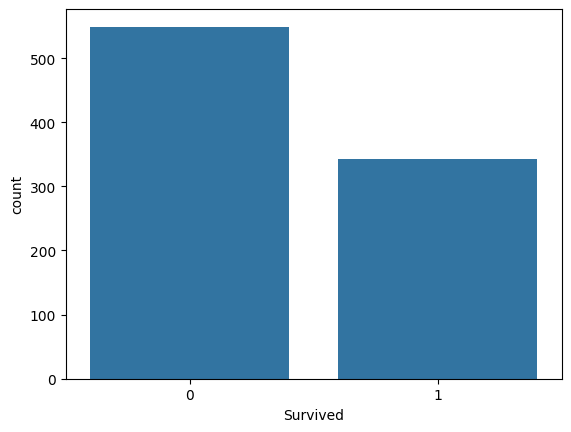

In [46]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

<Axes: xlabel='Survived', ylabel='count'>

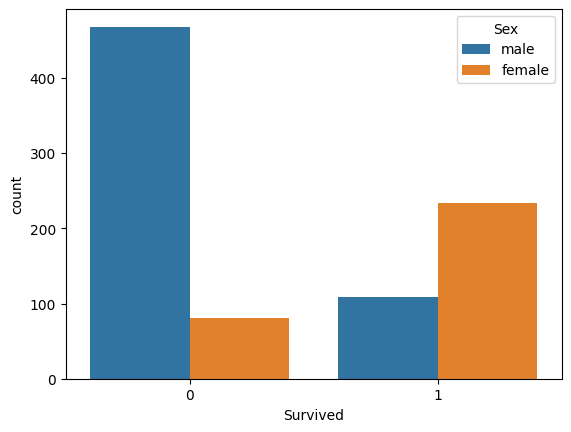

In [47]:
sb.countplot(x="Survived", data=datos, hue="Sex")

Sumamos los Datos

In [48]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Graficamos Los Datos de la edad para poder vizualizar cual era la media de la edad de los pasajeros

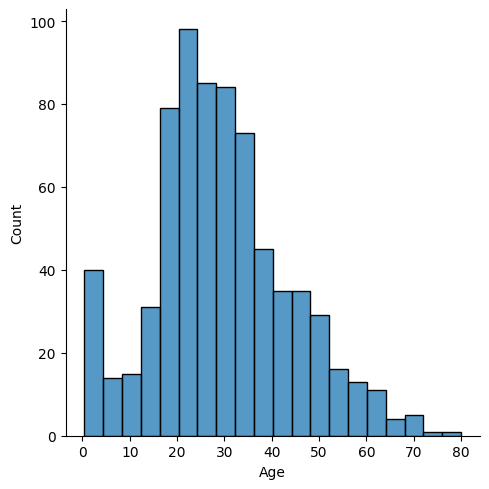

In [49]:
sb.displot(x="Age", data=datos)

Vizualizamos las edades de los pasajeros

In [50]:
datos['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


La Media de la edad

In [51]:
datos['Age'].mean()

np.float64(29.69911764705882)

Rellena Los Espacios Vacios

In [52]:
datos['Age'].fillna(datos['Age'].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [53]:
datos["Age"] = datos['Age'].fillna(datos['Age'].mean())

Vemos Los Datos Actualizados

In [54]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Vemos que la Edad Ya no tiene Espacios Vacios

In [55]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Borramos Cabin

In [56]:
datos= datos.drop(["Cabin"],axis=1)

Vemos EL Contenido de Embarked

In [57]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Hace Que nos Quedemos solo con las filas completas y que no tengan datos faltantes

In [58]:
datos = datos.dropna()

Vizualizamos Los Datos Actualizados

In [59]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Borramos Las filas "Name,PassengerId y Ticket"

In [60]:
datos = datos.drop(["Name","PassengerId","Ticket"],axis=1)

Convierte Los sexos en 0 y 1 para hacerlos datos numericos

In [61]:
dummies_sex = pd.get_dummies(datos["Sex"],drop_first= True)

Actualizamos Los datos y eliminamos los anteriores

In [62]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"],axis=1)

Vizualizamos con seaborn que tipo de embarcacion tenia mas oportunidad de sobrevivir con tu genero

<Axes: xlabel='Survived', ylabel='count'>

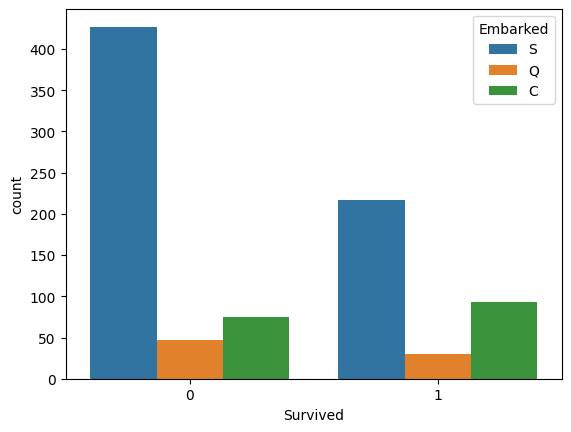

In [63]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

Creamos una nueva variable para hacer numerico la fila embarked

In [64]:
dummies_embarked = pd.get_dummies(datos["Embarked"],drop_first= True)

Actualizamos y borramos los datos

In [65]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"],axis=1)

Hacemos una matriz de confusion para vizualizar datos comunes

<Axes: >

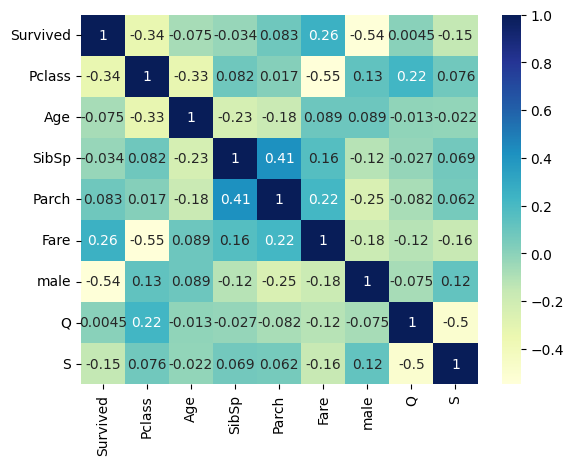

In [66]:
sb.heatmap(datos.corr(), annot=True,cmap="YlGnBu")

Usamos seaborn para vizualizar que clase sobrevivio mas

<Axes: xlabel='Survived', ylabel='count'>

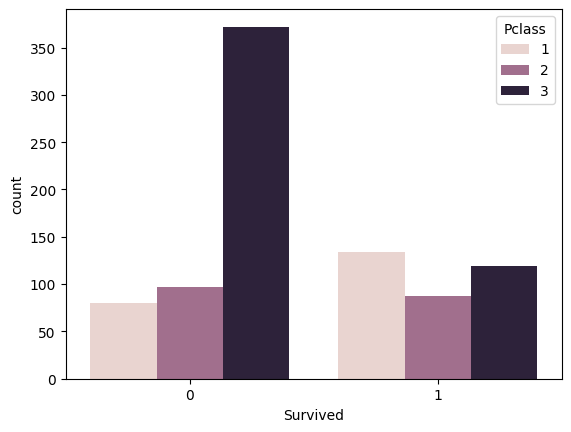

In [67]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [ ]:
Eliminamos y actualizamos  los datos de los sobrevivientes

In [78]:
x = datos.drop(["Survived"],axis=1)
y = datos["Survived"]

Usamos Sklearn para crear un modelo de de machine learning

In [69]:
from sklearn.model_selection import train_test_split
x_ent,x_pru,y_ent,y_pru = train_test_split(x,y,test_size=0.2)

ahora creamos un modelo de regresion losgistica

In [70]:
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_ent,y_ent)

LogisticRegression(max_iter=1000)

Hacemos una variable de predicciones que contiene el modelo predictivo

In [71]:
predicciones = modelo.predict(x_pru)

Nos dice su porcentaje de efectividad

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru,predicciones)

0.8089887640449438

Hace un reporte de los modelos de clasificacion

In [73]:
from sklearn.metrics import classification_report
print(classification_report(y_pru,predicciones))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       102
           1       0.83      0.70      0.76        76

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



Crea una matriz de confusión, que muestra cómo se comporta tu modelo clasificando

In [74]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pru,predicciones)

array([[91, 11],
       [23, 53]])

Transforma la matriz de confucion en una tabla mas legible

In [75]:
pd.DataFrame(confusion_matrix(y_pru,predicciones),columns=["Pred: No","Pred: Si"],index=["Real: No","Real: Si"])

,Pred: No,Pred: Si
Real: No,91,11
Real: Si,23,53


Mostramos los datos

In [76]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


Hacemos una prueba de nuestro modelo

In [77]:
nueva_persona = [3,35,0,0,10,1,0,0]
prediccion = modelo.predict([nueva_persona])
if prediccion[0] == 1:
  print("sobrevivirá")
else:
  print("sobrevivirá")

sobrevivirá


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
